Data preview:
             Image  GT_Count  TP  FP  FN  Time_ms
0    1edited_3.jpg        11   8   2   3      470
1   6edited_57.jpg         1   1   0   0      459
2  9edited_170.jpg         2   1   3   1      462
3  9edited_177.jpg         1   1   5   0      465
4  9edited_185.jpg         1   1   2   0      461

Total Images: 39
Total GT: 92, TP: 67, FP: 74, FN: 25
Average Inference Time: 461.92 ms

First 5 rows with Precision/Recall/F1:
             Image  Precision    Recall        F1
0    1edited_3.jpg   0.800000  0.727273  0.761905
1   6edited_57.jpg   1.000000  1.000000  1.000000
2  9edited_170.jpg   0.250000  0.500000  0.333333
3  9edited_177.jpg   0.166667  1.000000  0.285714
4  9edited_185.jpg   0.333333  1.000000  0.500000


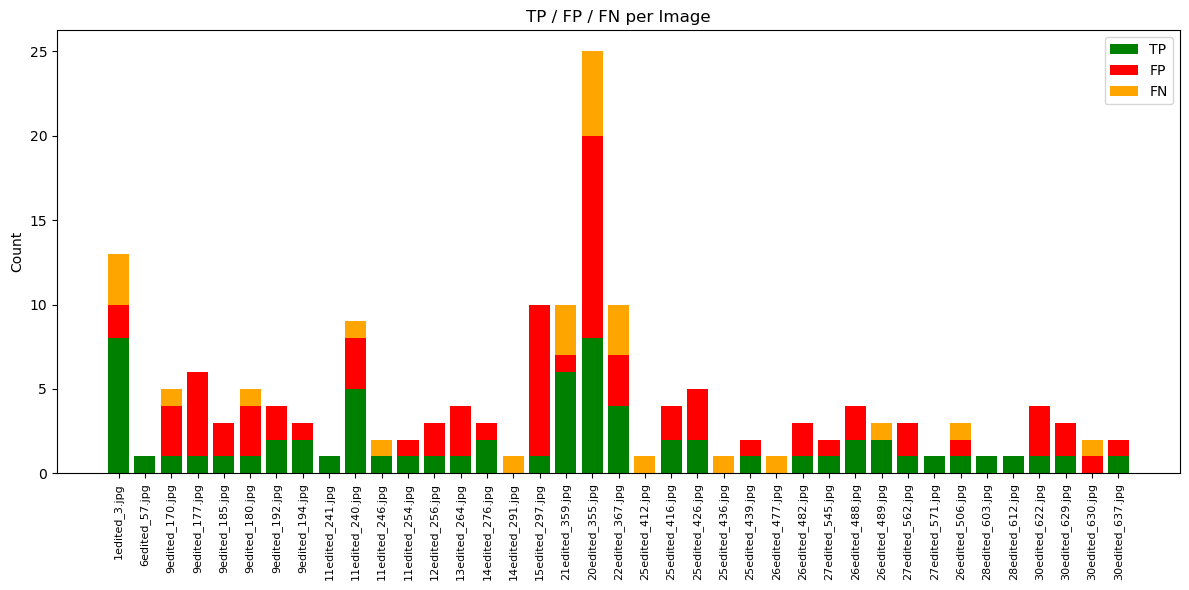

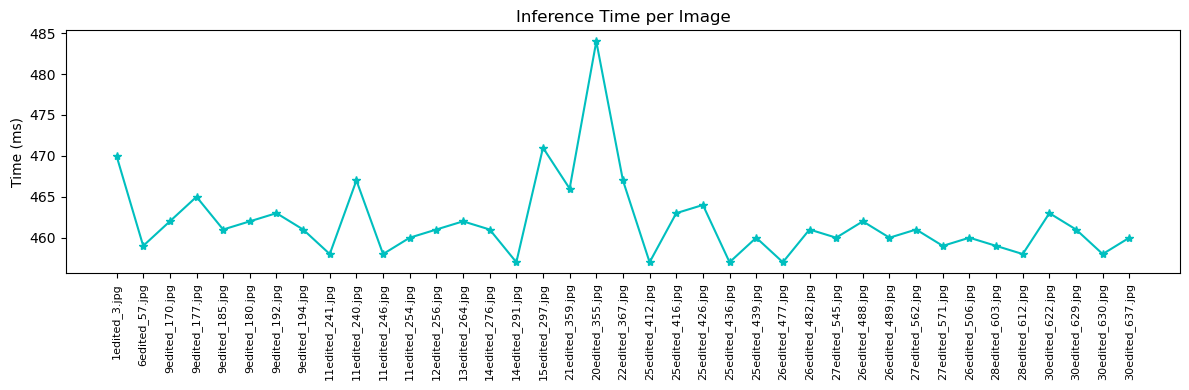


Summary Stats:
{'Total Images': 39, 'Total GT': np.int64(92), 'Total TP': np.int64(67), 'Total FP': np.int64(74), 'Total FN': np.int64(25), 'Average Time (ms)': np.float64(461.9230769230769), 'Overall Precision': np.float64(0.475177304964539), 'Overall Recall': np.float64(0.7282608695652174)}


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Load Data ----------
csv_file = "results.csv"  # replace with your actual file
df = pd.read_csv(csv_file)

print("Data preview:")
print(df.head())

# ---------- Summary Statistics ----------
total_images = len(df)
total_gt = df['GT_Count'].sum()
total_tp = df['TP'].sum()
total_fp = df['FP'].sum()
total_fn = df['FN'].sum()
avg_time = df['Time_ms'].mean()

print(f"\nTotal Images: {total_images}")
print(f"Total GT: {total_gt}, TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
print(f"Average Inference Time: {avg_time:.2f} ms")

# ---------- Metrics ----------
df['Precision'] = df['TP'] / (df['TP'] + df['FP']).replace(0, 1)
df['Recall'] = df['TP'] / (df['TP'] + df['FN']).replace(0, 1)
df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall']).replace(0, 1)

print("\nFirst 5 rows with Precision/Recall/F1:")
print(df[['Image','Precision','Recall','F1']].head())

# ---------- Plot 1: TP, FP, FN per image ----------
plt.figure(figsize=(12,6))
plt.bar(df['Image'], df['TP'], label='TP', color='green')
plt.bar(df['Image'], df['FP'], bottom=df['TP'], label='FP', color='red')
plt.bar(df['Image'], df['FN'], bottom=df['TP']+df['FP'], label='FN', color='orange')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Count")
plt.title("TP / FP / FN per Image")
plt.legend()
plt.tight_layout()
plt.show()



# ---------- Plot 3: Inference Time ----------
plt.figure(figsize=(12,4))
plt.plot(df['Image'], df['Time_ms'], 'c*-')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Time (ms)")
plt.title("Inference Time per Image")
plt.tight_layout()
plt.show()

# ---------- Save Summary ----------
summary = {
    "Total Images": total_images,
    "Total GT": total_gt,
    "Total TP": total_tp,
    "Total FP": total_fp,
    "Total FN": total_fn,
    "Average Time (ms)": avg_time,
    "Overall Precision": total_tp / max(total_tp + total_fp,1),
    "Overall Recall": total_tp / max(total_tp + total_fn,1)
}
print("\nSummary Stats:")
print(summary)


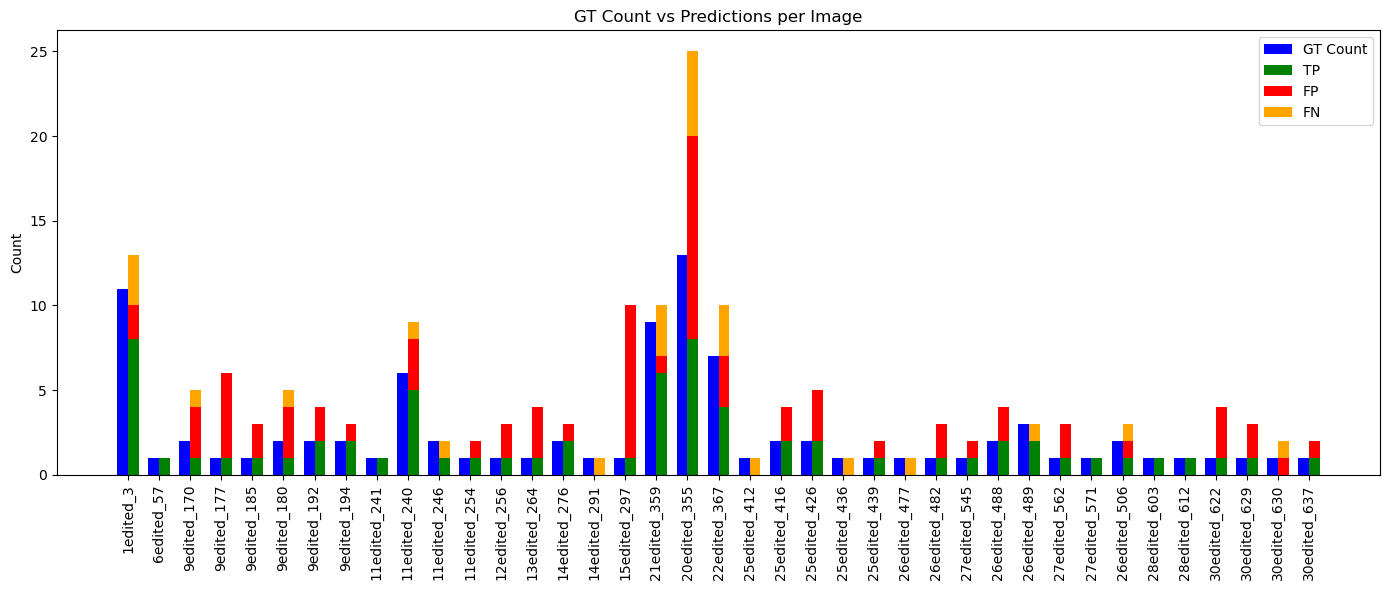

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- Load Data ----------
csv_file = "results.csv"
df = pd.read_csv(csv_file)
df['Image_short'] = df['Image'].str.replace(".jpg", "")  # shorter labels

# ---------- Prepare data ----------
images = df['Image_short']
gt_counts = df['GT_Count'].values
# Sum predictions for stacked bars
pred_stack = np.vstack([df['TP'], df['FP'], df['FN']])

x = np.arange(len(images))  # positions for each group
width = 0.35  # width of each bar

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(14,6))

# GT bars
ax.bar(x - width/2, gt_counts, width, label='GT Count', color='blue')

# Prediction bars stacked (TP, FP, FN)
ax.bar(x + width/2, df['TP'], width, label='TP', color='green')
ax.bar(x + width/2, df['FP'], width, bottom=df['TP'], label='FP', color='red')
ax.bar(x + width/2, df['FN'], width, bottom=df['TP'] + df['FP'], label='FN', color='orange')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(images, rotation=90)
ax.set_ylabel("Count")
ax.set_title("GT Count vs Predictions per Image")
ax.legend()
plt.tight_layout()
plt.show()
